In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
from imblearn.over_sampling import SMOTE
from collections import Counter

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [2]:
diabetes_dataset = pd.read_csv('5k data.csv')
diabetes_dataset.sample(5)

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
1932,28,Female,100,158,88,7.50,1.55,75.0,31.24,0,0,0,0,0,No
1211,48,Female,76,128,84,5.93,1.60,63.2,24.68,0,0,0,0,0,No
412,36,Female,85,110,73,6.00,1.49,46.0,20.72,0,0,0,0,0,No
1040,46,Female,69,152,106,7.00,1.37,54.0,28.77,0,0,0,0,0,No
5017,40,Female,74,139,86,5.26,1.27,58.4,36.21,1,0,1,0,0,No


In [3]:
diabetes_dataset.shape

(5288, 15)

In [4]:
diabetes_dataset['diabetic'].value_counts()

diabetic
No     4946
Yes     342
Name: count, dtype: int64

In [5]:
diabetes_dataset.groupby('diabetic').mean(numeric_only=True)

,age,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke
diabetic,,,,,,,,,,,,,
No,45.427416,76.46300,133.085321,81.717954,7.327325,1.548233,53.358310,22.366444,0.032956,0.081480,0.034371,0.008694,0.003235
Yes,50.347953,78.98538,147.175439,89.628655,10.985585,1.558333,57.777193,23.914766,0.017544,0.538012,0.023392,0.049708,0.011696


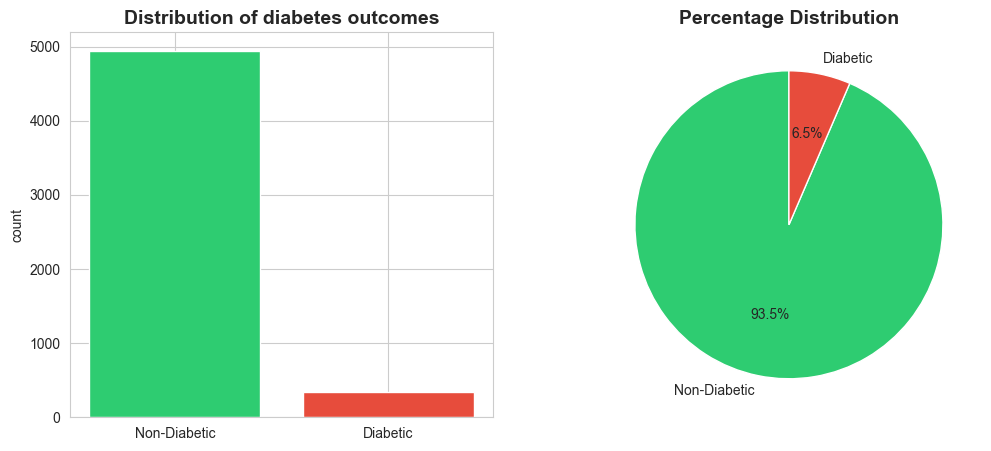

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
outcome_counts = diabetes_dataset['diabetic'].value_counts()
plt.bar(['Non-Diabetic', 'Diabetic'], outcome_counts.values, color=['#2ecc71', '#e74c3c'])
plt.title('Distribution of diabetes outcomes', fontsize=14, fontweight='bold')
plt.ylabel('count')

plt.subplot(1, 2, 2)
plt.pie(outcome_counts.values, labels=['Non-Diabetic', 'Diabetic'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Percentage Distribution', fontsize=14, fontweight='bold')

plt.show()

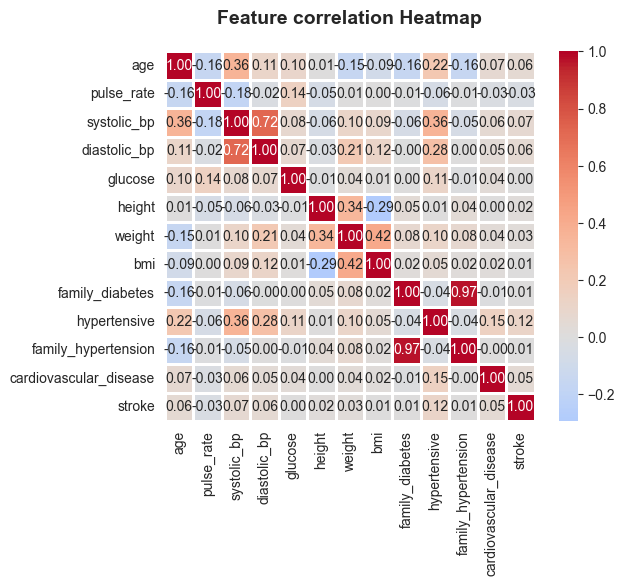

In [7]:
plt.Figure(figsize=(10,8))
correlation = diabetes_dataset.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square= True, linewidth=1, fmt='.2f')
plt.title('Feature correlation Heatmap', fontsize=14, pad=20, fontweight='bold')
plt.show()

In [8]:
diabetes_dataset['gender'] = diabetes_dataset['gender'].map({'Female': 0, 'Male': 1})
x = diabetes_dataset.drop(columns='diabetic', axis=1)
y = diabetes_dataset['diabetic']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, stratify= y, random_state=2)

print(x.shape, x_train.shape, x_test.shape)

(5288, 14) (4230, 14) (1058, 14)


In [10]:
scalar = StandardScaler()
x = scalar.fit_transform(x)

x

array([[-0.27909388, -0.6398294 , -0.86898865, ..., -0.18663778,
        -0.10712919, -0.0616158 ],
       [-0.80067408, -0.6398294 , -1.35965926, ..., -0.18663778,
        -0.10712919, -0.0616158 ],
       [ 1.21113527, -0.6398294 , -1.60499456, ..., -0.18663778,
        -0.10712919, -0.0616158 ],
       ...,
       [-0.42811679, -0.6398294 , -0.78721022, ..., -0.18663778,
        -0.10712919, 16.22960258],
       [-0.72616262, -0.6398294 , -1.19610239, ..., -0.18663778,
        -0.10712919, -0.0616158 ],
       [-1.4712772 , -0.6398294 ,  0.27590943, ..., -0.18663778,
        -0.10712919, -0.0616158 ]], shape=(5288, 14))

In [11]:
print("Before:", Counter(y))

smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x, y)

print("After:", Counter(y_train_sm))

Before: Counter({'No': 4946, 'Yes': 342})
After: Counter({'No': 4946, 'Yes': 4946})


In [12]:
classifier = svm.SVC(kernel='linear',class_weight='balanced', probability= True)
classifier.fit(x_train_sm, y_train_sm)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [13]:
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)
training_data_accuracy

0.06477541371158392

In [14]:
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)
test_data_accuracy

0.06427221172022685

In [15]:
y_pred_binary = np.where(np.array(x_test_prediction) == 'Yes', 1, 0)
y_test_binary = np.where(np.array(y_test) == 'Yes', 1, 0)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
f1 = f1_score(y_test_binary, y_pred_binary)

print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")

Precision: 0.06, Recall: 1.00, F1-Score: 0.12


In [16]:
cm_svm = confusion_matrix(y_test, x_test_prediction)
cm_svm

array([[  0, 990],
       [  0,  68]])

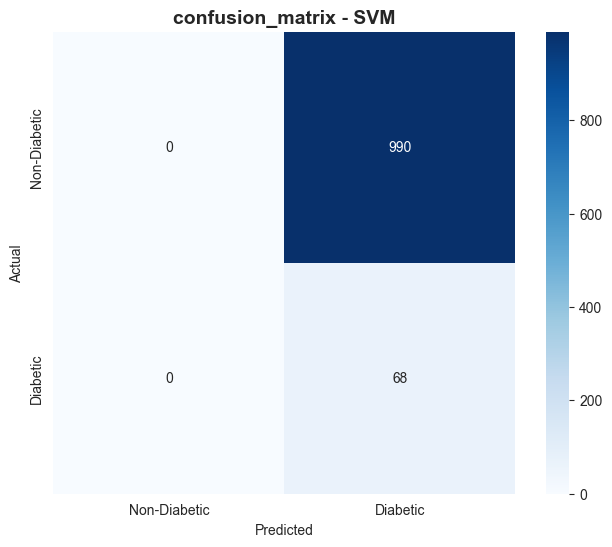

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot= True, fmt='d', cmap='Blues',square=True,
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.title('confusion_matrix - SVM', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [18]:
rf_classifier = RandomForestClassifier(n_estimators=100,random_state=2)
rf_classifier.fit(x_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
x_test_prediction_rf = rf_classifier.predict(x_train)
training_data_accuracy_rf = accuracy_score(x_train_prediction, y_train)
training_data_accuracy_rf

0.06477541371158392

In [20]:
x_test_prediction_rf = rf_classifier.predict(x_test)
test_data_accuracy_rf = accuracy_score(x_test_prediction, y_test)
test_data_accuracy_rf

0.06427221172022685

In [21]:
y_pred_binary = np.where(np.array(x_test_prediction_rf) == 'Yes', 1, 0)
y_test_binary = np.where(np.array(y_test) == 'Yes', 1, 0)
precision_rf = precision_score(y_test_binary, y_pred_binary)
recall_rf = recall_score(y_test_binary, y_pred_binary)
f1_rf = f1_score(y_test_binary, y_pred_binary)

print(f"Precision: {precision_rf:.2f}, Recall: {recall_rf:.2f}, F1-Score: {f1_rf:.2f}")

Precision: 0.00, Recall: 0.00, F1-Score: 0.00


In [22]:
cm_rf = confusion_matrix(y_test, x_test_prediction_rf)
cm_rf

array([[990,   0],
       [ 68,   0]])

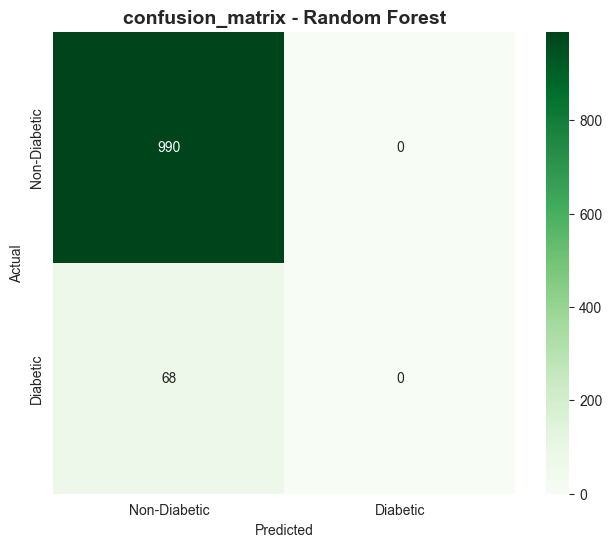

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot= True, fmt='d', cmap='Greens',square=True,
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.title('confusion_matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [24]:

nb_classifier = GaussianNB()
nb_classifier.fit(x_train_sm, y_train_sm)

x_test_prediction_nb = nb_classifier.predict(x_test)

test_data_accuracy_nb = accuracy_score(y_test, x_test_prediction_nb)
print(f"Naive Bayes Accuracy: {test_data_accuracy_nb}")



Naive Bayes Accuracy: 0.9357277882797732


In [25]:
dt_classifier = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_classifier.fit(x_train_sm, y_train_sm)

x_test_prediction_dt = dt_classifier.predict(x_test)

test_data_accuracy_dt = accuracy_score(y_test, x_test_prediction_dt)
print(f"Decision Tree Accuracy: {test_data_accuracy_dt:.4f}")


Decision Tree Accuracy: 0.9357


In [26]:
lr_model = LogisticRegression(solver='liblinear', class_weight='balanced')
lr_model.fit(x_train_sm, y_train_sm)

x_test_prediction_lr = lr_model.predict(x_test)

test_data_accuracy_lr = accuracy_score(y_test, x_test_prediction_lr)
print(f"Logistic Regression Accuracy: {test_data_accuracy_lr:.4f}")


Logistic Regression Accuracy: 0.0643


In [27]:
gb_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_classifier.fit(x_train_sm, y_train_sm)

x_test_prediction_gb = gb_classifier.predict(x_test)

test_data_accuracy_gb = accuracy_score(y_test, x_test_prediction_gb)
precision_gb = precision_score(y_test, x_test_prediction_gb, pos_label='Yes')
recall_gb = recall_score(y_test, x_test_prediction_gb, pos_label='Yes')
f1_gb = f1_score(y_test, x_test_prediction_gb, pos_label='Yes')

print(f"Gradient Boosting Accuracy: {test_data_accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1 Score: {f1_gb:.4f}")


Gradient Boosting Accuracy: 0.9319
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


In [28]:
print(f"svm: {test_data_accuracy:.4f}")
print(f"Random Forest: {test_data_accuracy_rf:.4f}")
print(f"Naive Bayes Accuracy: {test_data_accuracy_nb:.4f}")
print(f"Decision Tree Accuracy: {test_data_accuracy_dt:.4f}")
print(f"Logistic Regression Accuracy: {test_data_accuracy_lr:.4f}")
print(f"Gradient Boosting Accuracy: {test_data_accuracy_gb:.4f}")

svm: 0.0643
Random Forest: 0.0643
Naive Bayes Accuracy: 0.9357
Decision Tree Accuracy: 0.9357
Logistic Regression Accuracy: 0.0643
Gradient Boosting Accuracy: 0.9319


In [29]:

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

dt_classifier.fit(x_train_scaled, y_train)

joblib.dump(dt_classifier, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [30]:
diabetes_dataset.sample(20)


,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
4920,65,0,78,164,76,4.15,1.52,38.1,16.40,0,1,0,0,0,Yes
1390,60,0,72,139,72,5.78,1.50,52.1,23.20,0,0,0,0,0,No
3660,30,1,68,156,98,6.67,1.60,62.0,24.21,1,0,1,0,0,No
314,52,1,70,133,65,6.00,1.65,52.0,19.10,0,0,0,0,0,No
3724,55,0,80,151,90,8.27,1.52,58.0,24.97,0,0,0,0,0,No
190,44,0,76,133,75,6.00,1.39,40.0,20.70,0,1,0,0,0,No
4023,34,1,69,143,89,5.88,1.60,71.5,27.92,0,0,0,0,0,No
1094,35,1,85,124,79,9.36,1.68,80.1,28.50,0,0,0,0,0,No
1001,40,1,73,136,83,6.65,1.70,62.0,21.41,0,0,0,0,0,No
3743,55,0,74,160,93,5.21,1.52,57.2,24.63,0,0,0,0,0,No


In [31]:
input_data = (43,1,72,135,91,6.55,1.68,65.0,23.13,1,0,1,0,0)
input_num_array = np.asarray(input_data)
reshape = input_num_array.reshape(1,-1)

std_data = scalar.transform(reshape)
prediction = dt_classifier.predict(std_data)
prediction

array(['Yes'], dtype=object)